In [2]:
!pip install lifelines

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.datasets import load_rossi
from lifelines.statistics import logrank_test

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=0d269eaa711f668e4fad1fe6a7041224b1da6579ca0f7901de4cd45423c164f2
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [3]:
df = load_rossi()

df.head()

,week,arrest,fin,age,race,wexp,mar,paro,prio
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3


In [4]:
df.describe()

,week,arrest,fin,age,race,wexp,mar,paro,prio
count,432.000000,432.000000,432.00000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000
mean,45.854167,0.263889,0.50000,24.597222,0.877315,0.571759,0.122685,0.618056,2.983796
std,12.662293,0.441251,0.50058,6.113375,0.328456,0.495398,0.328456,0.486426,2.896068
min,1.000000,0.000000,0.00000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50.000000,0.000000,0.00000,20.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,52.000000,0.000000,0.50000,23.000000,1.000000,1.000000,0.000000,1.000000,2.000000
75%,52.000000,1.000000,1.00000,27.000000,1.000000,1.000000,0.000000,1.000000,4.000000
max,52.000000,1.000000,1.00000,44.000000,1.000000,1.000000,1.000000,1.000000,18.000000


In [5]:
df['arrest'].value_counts()

,count
arrest,
0,318
1,114


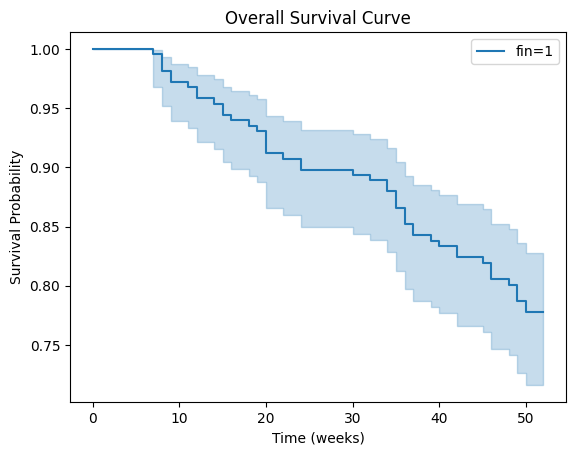

In [18]:
plt.figure()
kmf.plot_survival_function()
plt.title("Overall Survival Curve")
plt.xlabel("Time (weeks)")
plt.ylabel("Survival Probability")

plt.savefig("km_overall.png", dpi=300, bbox_inches="tight")
plt.show()

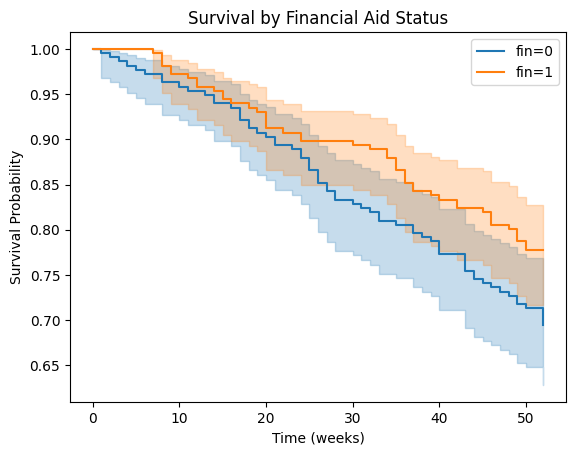

In [17]:
plt.figure()

for group in df['fin'].unique():
    mask = df['fin'] == group
    kmf.fit(df[mask]['week'], df[mask]['arrest'], label=f"fin={group}")
    kmf.plot_survival_function()

plt.title("Survival by Financial Aid Status")
plt.xlabel("Time (weeks)")
plt.ylabel("Survival Probability")

plt.savefig("km_by_fin.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
group0 = df[df['fin'] == 0]
group1 = df[df['fin'] == 1]

results = logrank_test(
    group0['week'], group1['week'],
    event_observed_A=group0['arrest'],
    event_observed_B=group1['arrest']
)

results.print_summary()

In [9]:
cph = CoxPHFitter()

cph.fit(df, duration_col='week', event_col='arrest')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -658.75
         time fit was run = 2026-03-02 04:28:54 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.38      0.68      0.19           -0.75           -0.00                0.47                1.00
age       -0.06      0.94      0.02           -0.10           -0.01                0.90                0.99
race       0.31      1.37      0.31           -0.29            0.92                0.75                2.50
wexp      -0.15      0.86      0.21           -0.57            0.27                0.57                1.30
mar       -0.43      0.65      0.38           -1.18            0.31                0.31                1.37
paro      -0.08      0.92      0.20           -0.47            0.30                0.63                1.35
prio       0.09      1.10      0.03            0.04            0.15                1.04                1.16

           cmp to     z      p  -log2(p)
covariate                               
fin          0.00 -1.98   0.05      4.40
age          0.00 -2.61   0.01      6.79
race         0.00  1.02   0.31      1.70
wexp         0.00 -0.71   0.48      1.06
mar          0.00 -1.14   0.26      1.97
paro         0.00 -0.43   0.66      0.59
prio         0.00  3.19 <0.005      9.48
---
Concordance = 0.64
Partial AIC = 1331.50
log-likelihood ratio test = 33.27 on 7 df
-log2(p) of ll-ratio test = 15.37


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'age' failed the non-proportional test: p-value is 0.0007.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


2. Variable 'wexp' failed the non-proportional test: p-value is 0.0063.

   Advice: with so few unique values (only 2), you can include `strata=['wexp', ...]` in the call in
`.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a mome

[[<Axes: xlabel='rank-transformed time\n(p=0.9023)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8900)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0007)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0009)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2323)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2306)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0068)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0063)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3996)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4382)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7140)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7337)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8908)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8806)'>]]

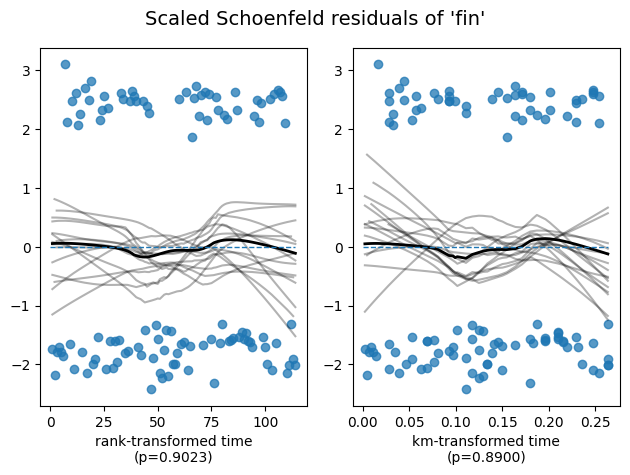

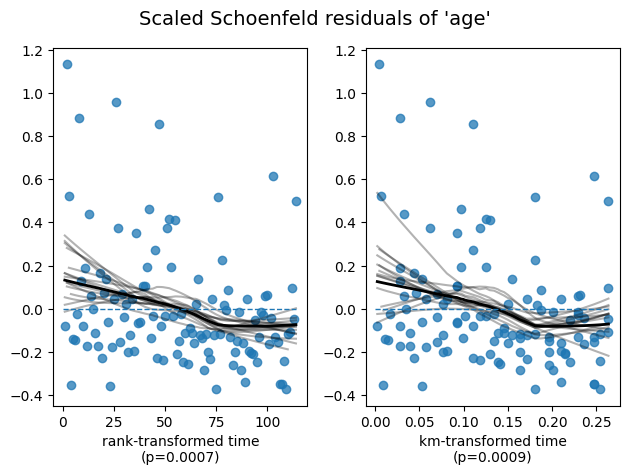

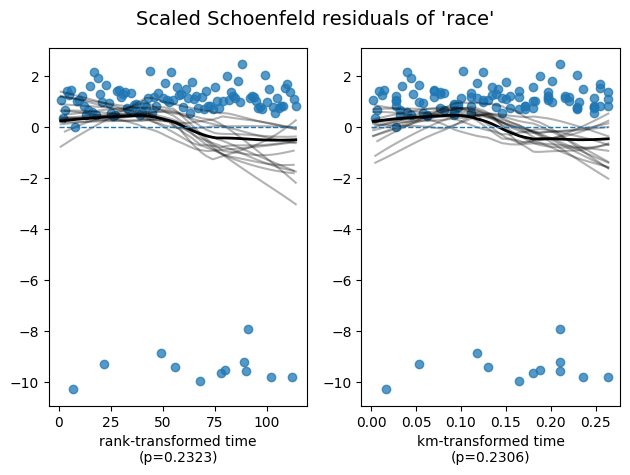

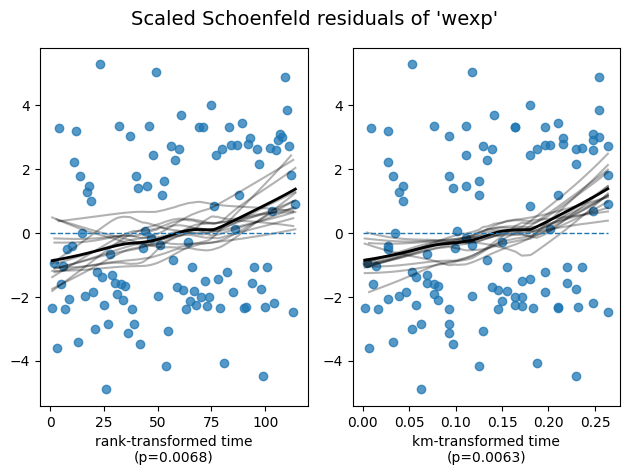

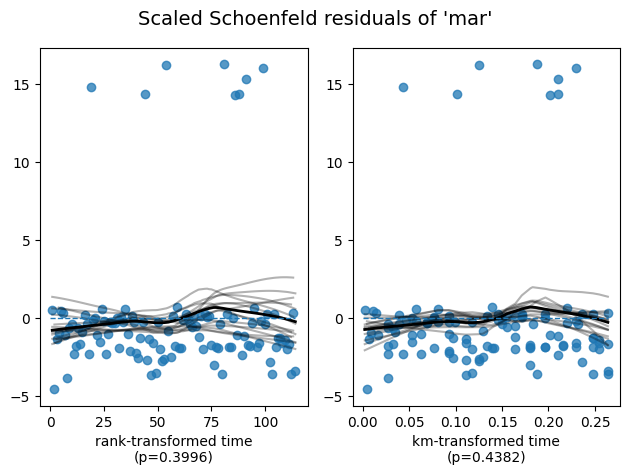

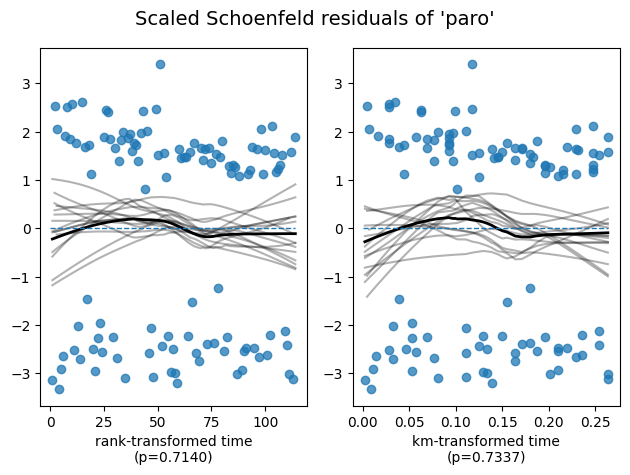

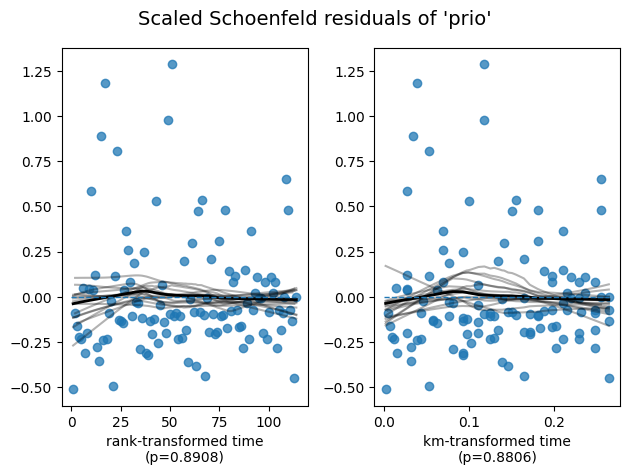

In [10]:
cph.check_assumptions(df, show_plots=True)

# Proportional Hazards Assumption

The proportional hazards assumption was assessed using Schoenfeld residual-based tests.

Evidence of non-proportionality was observed for age (p < 0.005) and work experience (wexp) (p ≈ 0.006), suggesting that the effects of these variables may vary over time.

Other covariates, including financial aid (fin), prior convictions (prio), race, marital status, and parole status, did not show evidence of violation.

Given these findings, the estimated hazard ratios for age and work experience should be interpreted with caution, as their effects may not remain constant over the follow-up period.